# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
steam = pd.read_csv("steam.csv")

print("Jumlah data:", len(steam))
steam.head()

Jumlah data: 27075


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


# Data Understanding

In [ ]:
df = steam[
    [
        "name",
        "genres",
        "positive_ratings",
        "negative_ratings",
        "average_playtime",
        "owners",
        "price"
    ]
]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              27075 non-null  object 
 1   genres            27075 non-null  object 
 2   positive_ratings  27075 non-null  int64  
 3   negative_ratings  27075 non-null  int64  
 4   average_playtime  27075 non-null  int64  
 5   owners            27075 non-null  object 
 6   price             27075 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 1.4+ MB


# Data Preprocessing & Feature Engineering


In [ ]:
# Mengecek missing value

print("Missing Values:")
print(df.isnull().sum())

# Convert Owners to Numeric Value

def owner_midpoint(owner):
  low, high = owner.split("-")
  return (int(low) + int(high)) / 2

df["owner_mid"] = df["owners"].apply(owner_midpoint)

# Total Ratings

df["total_ratings"] = (
df["positive_ratings"] +
df["negative_ratings"]
)

# Rating Ratio

df["rating_ratio"] = (
df["positive_ratings"] /
(df["total_ratings"] + 1)
)

# Digunakan untuk mengurangi skewness data

df["log_playtime"] = np.log1p(df["average_playtime"])
df["log_owners"] = np.log1p(df["owner_mid"])
df["log_total_ratings"] = np.log1p(df["total_ratings"])

# Preview Hasil

df[
    [
    "name",
    "owner_mid",
    "total_ratings",
    "rating_ratio",
    "log_playtime",
    "log_owners"
    ]
].head()


Missing Values:
name                0
genres              0
positive_ratings    0
negative_ratings    0
average_playtime    0
owners              0
price               0
dtype: int64


/tmp/ipykernel_7247/3459035232.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["owner_mid"] = df["owners"].apply(owner_midpoint)
/tmp/ipykernel_7247/3459035232.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_ratings"] = (
/tmp/ipykernel_7247/3459035232.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

,name,owner_mid,total_ratings,rating_ratio,log_playtime,log_owners
0,Counter-Strike,15000000.0,127873,0.973881,9.776393,16.523561
1,Team Fortress Classic,7500000.0,3951,0.839575,5.627621,15.830414
2,Day of Defeat,7500000.0,3814,0.895413,5.236442,15.830414
3,Deathmatch Classic,7500000.0,1540,0.826087,5.556828,15.830414
4,Half-Life: Opposing Force,7500000.0,5538,0.947825,6.437752,15.830414


# Exploratory Data Analysis (EDA)

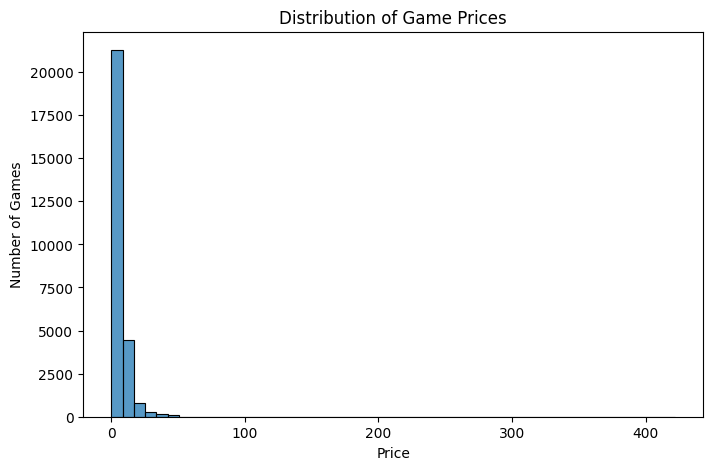

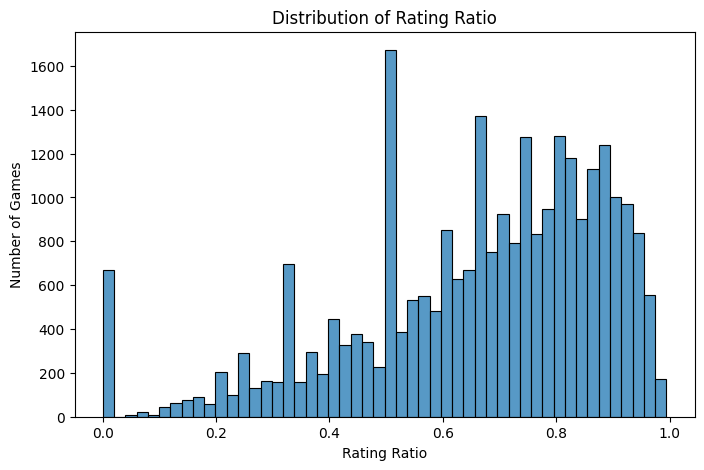

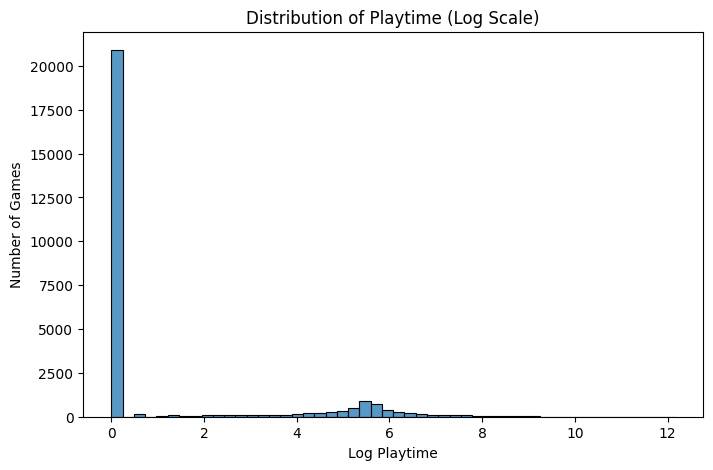

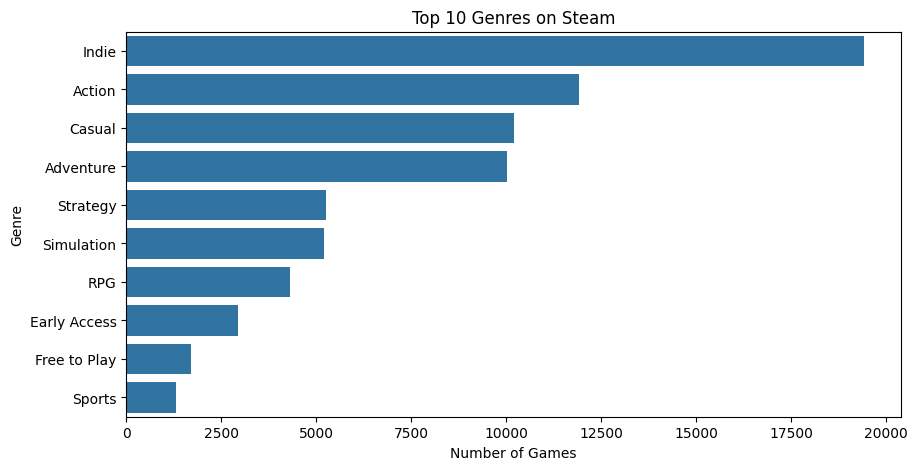

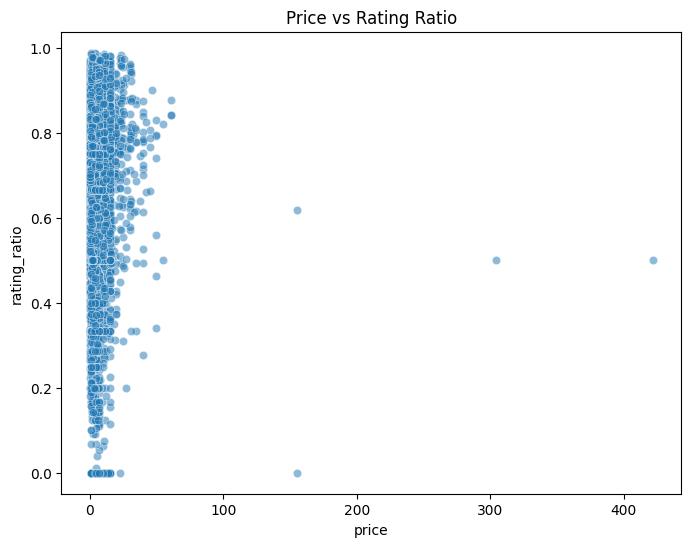

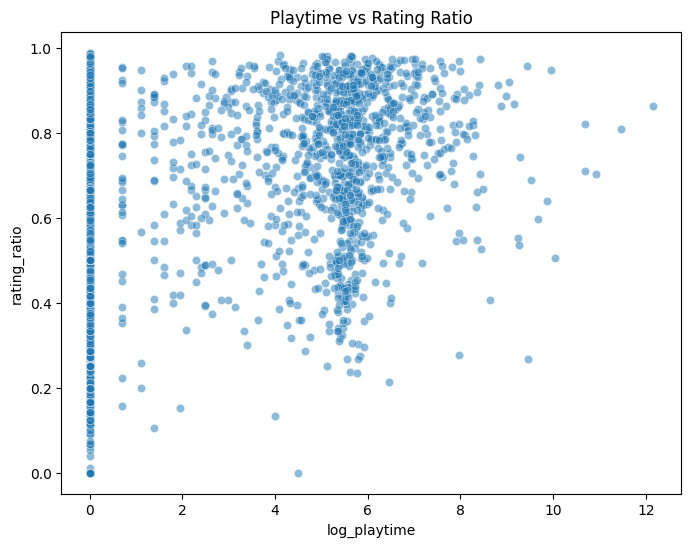

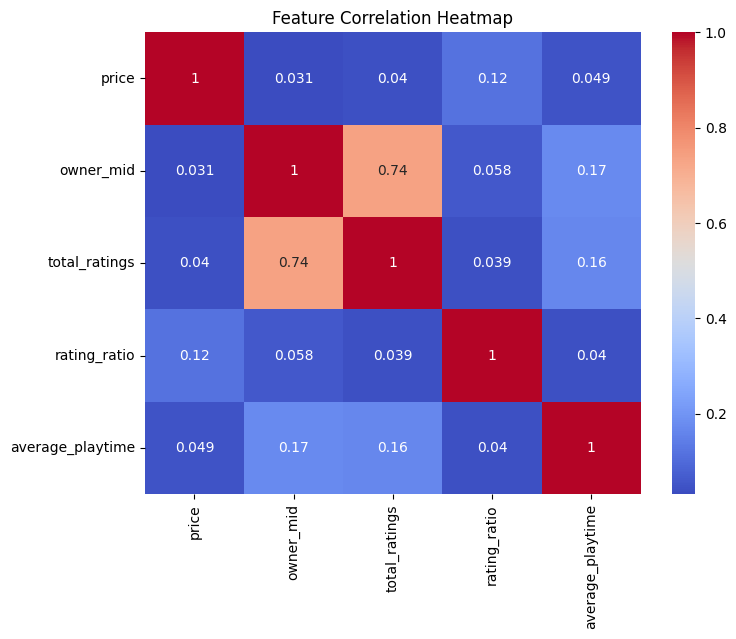

In [ ]:

df.describe()

# Distribution of Game Prices

plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50)

plt.title("Distribution of Game Prices")
plt.xlabel("Price")
plt.ylabel("Number of Games")
plt.show()

# Distribution of Rating Ratio

plt.figure(figsize=(8,5))
sns.histplot(df["rating_ratio"], bins=50)

plt.title("Distribution of Rating Ratio")
plt.xlabel("Rating Ratio")
plt.ylabel("Number of Games")
plt.show()

# Distribution of Playtime

plt.figure(figsize=(8,5))
sns.histplot(df["log_playtime"], bins=50)

plt.title("Distribution of Playtime (Log Scale)")
plt.xlabel("Log Playtime")
plt.ylabel("Number of Games")
plt.show()

# Top 10 Genres

genre_series = (df["genres"].str.split(";").explode())
top_genres = genre_series.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Steam")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.show()

# Price vs Rating Ratio

sample_df = df.sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_df, x="price", y="rating_ratio", alpha=0.5)

plt.title("Price vs Rating Ratio")
plt.show()

# Playtime vs Rating Ratio

plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_df, x="log_playtime", y="rating_ratio", alpha=0.5)

plt.title("Playtime vs Rating Ratio")
plt.show()

# Correlation Heatmap

corr_columns = [
  "price",
  "owner_mid",
  "total_ratings",
  "rating_ratio",
  "average_playtime"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_columns].corr(),annot=True,cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


count    27075.000000
mean         0.329853
std          0.117580
min         -0.057751
25%          0.251440
50%          0.347370
75%          0.417937
max          0.689342
Name: hidden_gem_score, dtype: float64
Threshold : 0.5

Hidden Gem Distribution
hidden_gem
0    26284
1      791
Name: count, dtype: int64


/tmp/ipykernel_7247/884789553.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[
/tmp/ipykernel_7247/884789553.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[
/tmp/ipykernel_7247/884789553.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[
/tmp/ipyke

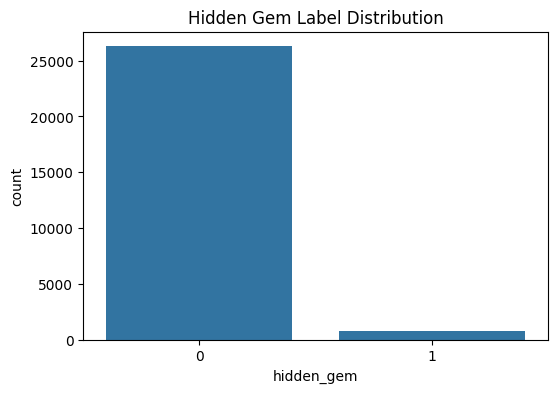


TOP 20 HIDDEN GEMS


,name,genres,price,rating_ratio,owner_mid,hidden_gem_score
12452,Pictopix,Casual;Indie;Strategy,4.99,0.941176,10000.0,0.689342
25754,HEARTBEAT,Indie;RPG,11.39,0.973118,10000.0,0.662184
15960,Shining Song Starnova,Casual,23.79,0.925000,10000.0,0.661584
9299,Floppy Heroes,Action;Casual;Indie,1.99,0.944664,10000.0,0.655848
12568,Angels with Scaly Wings,Violent;Adventure;Indie;RPG;Simulation,7.99,0.971239,10000.0,0.655738
8919,Screeps,Indie;Massively Multiplayer;Strategy,10.99,0.882494,35000.0,0.652401
9201,The Abbey of Crime Extensum,Adventure;Free to Play,0.00,0.863905,75000.0,0.650626
8471,Flowers -Le volume sur printemps-,Casual,14.99,0.974955,10000.0,0.647335
1585,Nancy Drew®: Ghost of Thornton Hall,Adventure,15.49,0.920635,10000.0,0.645668
12195,The Price of Freedom,Adventure;Indie,0.00,0.935393,75000.0,0.645469



Total Games : 27075
Hidden Gems : 791
Non Hidden Gems : 26284


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Feature Scaling

scaler = MinMaxScaler()

df[
    [
        "rating_ratio_scaled",
        "playtime_scaled",
        "owners_scaled"
    ]
] = scaler.fit_transform(
    df[
        [
            "rating_ratio",
            "log_playtime",
            "log_owners"
        ]
    ]
)

# Hidden Gem Score

df["hidden_gem_score"] = (
    (0.5 * df["rating_ratio_scaled"]) +
    (0.3 * df["playtime_scaled"]) -
    (0.4 * df["owners_scaled"])
)
print(df["hidden_gem_score"].describe())

# Threshold

threshold = 0.5
print("Threshold :", threshold)

# Hidden Gem Label

df["hidden_gem"] = (
    (df["hidden_gem_score"] >= threshold) & (df["owner_mid"] < 500000)
).astype(int)

# Distribution

print("\nHidden Gem Distribution")
print(df["hidden_gem"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df["hidden_gem"])

plt.title("Hidden Gem Label Distribution")
plt.show()

# Top Hidden Gems

top_hidden_gems = (
    df[df["hidden_gem"] == 1]
    .sort_values(
        by="hidden_gem_score",
        ascending=False
    )
)

print("\nTOP 20 HIDDEN GEMS")

display(
    top_hidden_gems[
        [
            "name",
            "genres",
            "price",
            "rating_ratio",
            "owner_mid",
            "hidden_gem_score"
        ]
    ].head(20)
)

print("\nTotal Games :", len(df))
print("Hidden Gems :", df["hidden_gem"].sum())
print("Non Hidden Gems :", len(df) - df["hidden_gem"].sum())

# K-Means Clustering


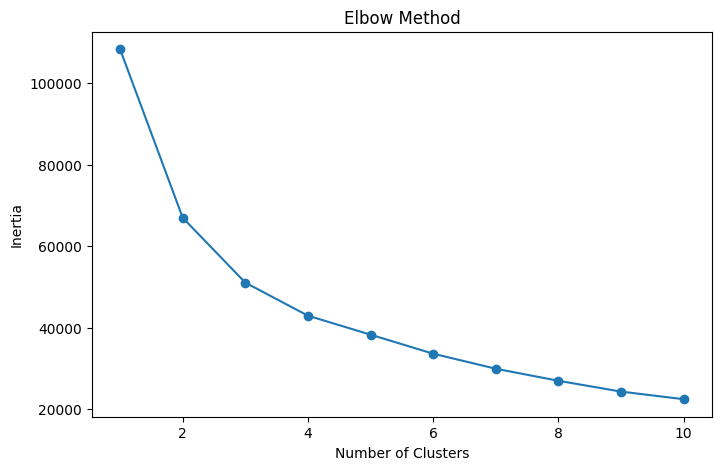

Cluster Distribution
cluster
0    13937
3     7229
2     5118
1      791
Name: count, dtype: int64


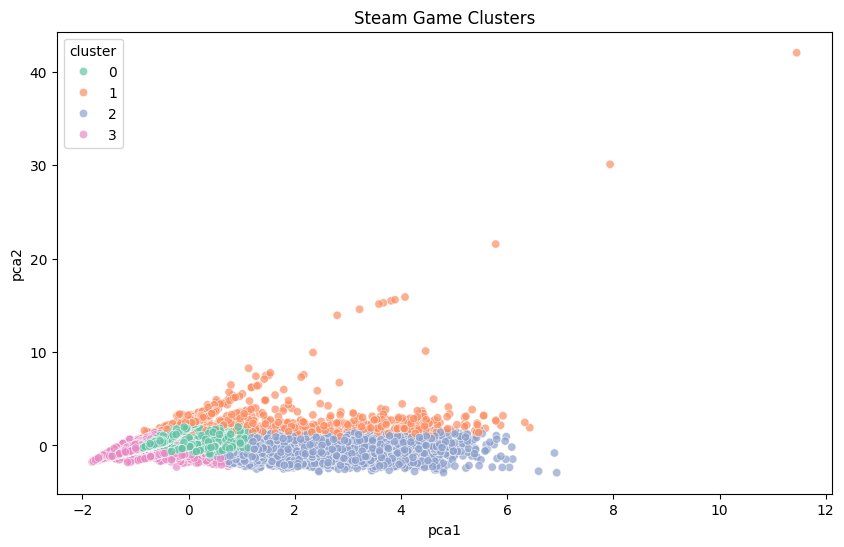

Cluster Summary


,price,rating_ratio,average_playtime,owner_mid
cluster,,,,
0,5.319163,0.777871,0.919782,18549.185621
1,34.126941,0.729136,618.731985,183021.491783
2,6.460496,0.745049,690.917741,609047.479484
3,4.201782,0.375466,2.436852,15231.013972


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Features for Clustering

cluster_features = [
    "price",
    "rating_ratio",
    "log_playtime",
    "log_owners"
]
X_cluster = df[cluster_features]

# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method

inertia = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Final KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster Distribution")
print(df["cluster"].value_counts())

# PCA Visualization

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["pca1"] = pca_result[:,0]
df["pca2"] = pca_result[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Steam Game Clusters")
plt.show()

# Cluster Summary

cluster_summary = df.groupby("cluster")[
    [
        "price",
        "rating_ratio",
        "average_playtime",
        "owner_mid"
    ]
].mean()

print("Cluster Summary")
display(cluster_summary)

# Decision Tree Classification

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Features dan Target

X = df[
    [
        "price",
        "rating_ratio",
        "log_playtime",
        "log_owners"
    ]
]

y = df["hidden_gem"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

# Training Model

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

# Prediction

y_pred = dt.predict(X_test)

Training Data : (21660, 4)
Testing Data  : (5415, 4)


# Model Evaluation

Accuracy : 0.9886

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5257
           1       0.86      0.73      0.79       158

    accuracy                           0.99      5415
   macro avg       0.93      0.86      0.89      5415
weighted avg       0.99      0.99      0.99      5415



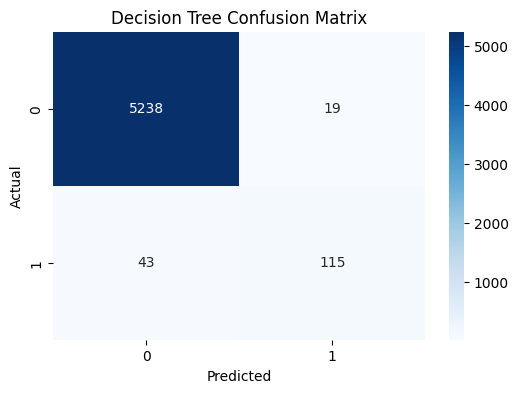

,Feature,Importance
1,rating_ratio,0.41883
3,log_owners,0.38684
2,log_playtime,0.19433
0,price,0.00000


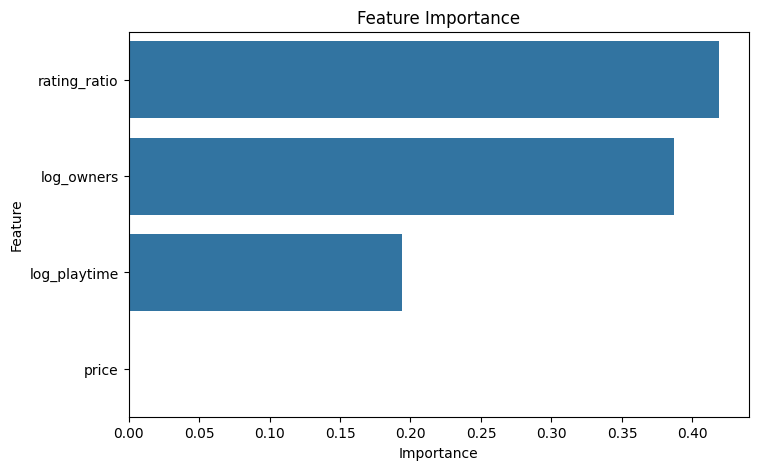

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", round(accuracy, 4))

# Classification Report

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# Hidden Gem Discovery & Recommendation

TOP 20 HIDDEN GEMS


,name,genres,price,rating_ratio,hidden_gem_score
12452,Pictopix,Casual;Indie;Strategy,4.99,0.941176,0.689342
25754,HEARTBEAT,Indie;RPG,11.39,0.973118,0.662184
15960,Shining Song Starnova,Casual,23.79,0.925000,0.661584
9299,Floppy Heroes,Action;Casual;Indie,1.99,0.944664,0.655848
12568,Angels with Scaly Wings,Violent;Adventure;Indie;RPG;Simulation,7.99,0.971239,0.655738
8919,Screeps,Indie;Massively Multiplayer;Strategy,10.99,0.882494,0.652401
9201,The Abbey of Crime Extensum,Adventure;Free to Play,0.00,0.863905,0.650626
8471,Flowers -Le volume sur printemps-,Casual,14.99,0.974955,0.647335
1585,Nancy Drew®: Ghost of Thornton Hall,Adventure,15.49,0.920635,0.645668
12195,The Price of Freedom,Adventure;Indie,0.00,0.935393,0.645469



TOP 10 HIDDEN RPG GAMES


,name,rating_ratio,hidden_gem_score
25754,HEARTBEAT,0.973118,0.662184
12568,Angels with Scaly Wings,0.971239,0.655738
4863,Snail Bob 2: Tiny Troubles,0.979381,0.633415
18173,Tales of Vesperia: Definitive Edition,0.892283,0.623490
13481,Shotgun Legend,0.956757,0.617473
4132,Winged Sakura: Mindy's Arc,0.869281,0.613353
2023,Fantasy Grounds,0.788703,0.607811
14087,Crystalline,0.969811,0.605613
14853,RESONANCE OF FATE™/END OF ETERNITY™ 4K/HD EDITION,0.836207,0.604226
10118,Detective Hayseed - Hollywood,0.914894,0.602948



TOP 10 HIDDEN STRATEGY GAMES


...

,name,rating_ratio,hidden_gem_score
12568,Angels with Scaly Wings,0.971239,0.655738
9201,The Abbey of Crime Extensum,0.863905,0.650626
1585,Nancy Drew®: Ghost of Thornton Hall,0.920635,0.645668
12195,The Price of Freedom,0.935393,0.645469
21136,Fureraba ~Friend to Lover~,0.983607,0.642101
23104,東方幕華祭 TouHou Makuka Sai ~ Fantastic Danmaku Fe...,0.962441,0.640527
21165,Isoland 2 - Ashes of Time,0.981928,0.638616
21066,Adventure of a Lifetime,0.949580,0.637305
9174,Higurashi When They Cry Hou - Ch.3 Tatarigoroshi,0.961749,0.635827
7976,Root Double -Before Crime * After Days- Xtend ...,0.939850,0.634974



TOP 10 HIDDEN ACTION GAMES


,name,rating_ratio,hidden_gem_score
9299,Floppy Heroes,0.944664,0.655848
23104,東方幕華祭 TouHou Makuka Sai ~ Fantastic Danmaku Fe...,0.962441,0.640527
6517,Trigonarium,0.950000,0.634443
4863,Snail Bob 2: Tiny Troubles,0.979381,0.633415
7900,RefRain - prism memories -,0.982143,0.633025
6164,Umihara Kawase,0.974359,0.628217
14482,Graze Counter,0.964286,0.627635
13481,Shotgun Legend,0.956757,0.617473
3160,Knightmare Tower,0.930456,0.617415
22041,Gal*Gun 2,0.913433,0.614591



TOP 10 HIDDEN INDIE GAMES


,name,rating_ratio,hidden_gem_score
12452,Pictopix,0.941176,0.689342
25754,HEARTBEAT,0.973118,0.662184
9299,Floppy Heroes,0.944664,0.655848
12568,Angels with Scaly Wings,0.971239,0.655738
8919,Screeps,0.882494,0.652401
12195,The Price of Freedom,0.935393,0.645469
23104,東方幕華祭 TouHou Makuka Sai ~ Fantastic Danmaku Fe...,0.962441,0.640527
18402,KARAKARA2,0.948655,0.640475
21165,Isoland 2 - Ashes of Time,0.981928,0.638616
10314,The Hex,0.958333,0.635123


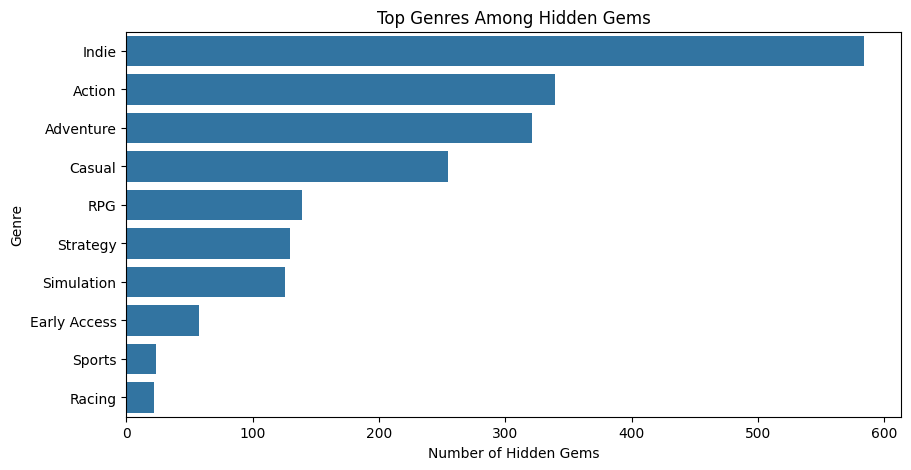

In [ ]:
# Ambil semua Hidden Gems

top_hidden_gems = (
    df[df["hidden_gem"] == 1]
    .sort_values(
        by="hidden_gem_score",
        ascending=False
    )
)

# Top 20 Hidden Gems Overall

print("=" * 60)
print("TOP 20 HIDDEN GEMS")
print("=" * 60)

display(
    top_hidden_gems[
        [
            "name",
            "genres",
            "price",
            "rating_ratio",
            "hidden_gem_score"
        ]
    ].head(20)
)

# Helper Function

def show_hidden_gems_by_genre(genre_name, top_n=10):
    genre_games = top_hidden_gems[
        top_hidden_gems["genres"].str.contains(
            genre_name,
            case=False,
            na=False
        )
    ]

    print("\n" + "=" * 60)
    print(f"TOP {top_n} HIDDEN {genre_name.upper()} GAMES")
    print("=" * 60)

    display(
        genre_games[
            [
                "name",
                "rating_ratio",
                "hidden_gem_score"
            ]
        ].head(top_n)
    )

# Hidden Gems by Genre

show_hidden_gems_by_genre("RPG")
show_hidden_gems_by_genre("Strategy")
show_hidden_gems_by_genre("Simulation")
show_hidden_gems_by_genre("Adventure")
show_hidden_gems_by_genre("Action")
show_hidden_gems_by_genre("Indie")

# Most COmmon Hidden Gem Genres

genre_series = (
    top_hidden_gems["genres"]
    .str.split(";")
    .explode()
)

top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top Genres Among Hidden Gems")
plt.xlabel("Number of Hidden Gems")
plt.ylabel("Genre")

plt.show()

# Steam Hidden Gem Checker

In [ ]:
print("=" * 60)
print("STEAM HIDDEN GEM CHECKER")
print("=" * 60)
print("Type 'exit' to quit")
print()

while True:

    game_name = input("Enter Game Name: ")

    if game_name.lower() == "exit":
        print("\nThanks for using Steam Hidden Gem Checker!")
        break

    result = df[
        df["name"].str.contains(
            game_name,
            case=False,
            na=False
        )
    ]

    if len(result) == 0:
        print("\n No matching game found.\n")
        continue

    game = result.iloc[0]

    game_features = pd.DataFrame({
        "price": [game["price"]],
        "rating_ratio": [game["rating_ratio"]],
        "log_playtime": [game["log_playtime"]],
        "log_owners": [game["log_owners"]]
    })

    prediction = dt.predict(game_features)[0]
    probability = dt.predict_proba(game_features)[0][1]

    print("\n" + "=" * 60)

    print("Game Name        :", game["name"])
    print("Genres           :", game["genres"])
    print("Price            :", game["price"])
    print("Rating Ratio     :", round(game["rating_ratio"] * 100, 2), "%")
    print("Average Playtime :", game["average_playtime"])
    print("Owners           :", game["owners"])

    print("\nPrediction")

    if prediction == 1:
        print("HIDDEN GEM\n")
    else:
        print("NOT HIDDEN GEM\n")

    if prediction == 1: confidence = probability
    else: confidence = 1 - probability
    print(f"Hidden Gem Score : {confidence:.2%}")

    print("\nReason:")

    if game["rating_ratio"] >= 0.8: print("Very High Rating")
    elif game["rating_ratio"] >= 0.6: print("High Rating")
    elif game["rating_ratio"] >= 0.4: print("Medium Rating")
    elif game["rating_ratio"] >= 0.2: print("Low Rating")

    if game["owner_mid"] < 500000: print("Relatively Unknown")
    else: print("Probably Known")

    if game["average_playtime"] > 1000: print("Strong Player Engagement")
    else: print("Weak Player Engagement")

    print("=" * 60)
    print()

STEAM HIDDEN GEM CHECKER
Type 'exit' to quit



KeyboardInterrupt: Interrupted by user

# Kesimpulan

Berdasarkan hasil analisis terhadap 27.075 game Steam, berhasil dibangun sistem Steam Hidden Gem Discovery menggunakan pendekatan Machine Learning.

Tahap clustering menggunakan K-Means berhasil mengelompokkan game berdasarkan karakteristik harga, rating, playtime, dan jumlah owners. Selanjutnya, Decision Tree digunakan untuk mengklasifikasikan game ke dalam kategori Hidden Gem dan Non Hidden Gem.

Hasil evaluasi menunjukkan akurasi sebesar 98,86%, dengan precision 86% dan recall 73% untuk kelas Hidden Gem.

Berdasarkan analisis feature importance, faktor yang paling berpengaruh dalam menentukan status hidden gem adalah Rating Ratio (41,88%), Log Owners (38,68%), dan Log Playtime (19,43%), sedangkan harga game tidak memberikan pengaruh yang signifikan.

Sistem yang dibangun juga mampu melakukan pengecekan status hidden gem secara interaktif berdasarkan nama game, menampilkan Hidden Gem Score, serta memberikan rekomendasi hidden gem lain yang relevan berdasarkan kesamaan genre. Implementasi sistem telah dikembangkan menjadi aplikasi web sehingga dapat digunakan secara lebih mudah oleh pengguna.

Dengan demikian, proyek ini menunjukkan bahwa kombinasi kualitas game, tingkat popularitas, dan keterlibatan pemain dapat digunakan untuk mengidentifikasi game-game berkualitas yang masih kurang dikenal oleh pemain Steam.